# 06-Window Functions & Stateful Bounding

In the previous lessons, we mastered distributed network physics. We learned how to shuffle data safely and eliminate bottlenecks using Apache Arrow and Broadcast Joins.

However, all the transformations we have built so far have been **Stateless**. A standard `.filter()` or `pandas_udf` evaluates each row in perfect isolation. Even a `.groupBy()` collapses thousands of rows into a single stateless scalar value.

In Enterprise data engineering, specifically in Time Series, Financial Analytics, and IoT pipelines, we must compute **Stateful Metrics**—like 30-day rolling averages, cumulative revenue sums, and sequential event ranking. We need to compute aggregates *without* collapsing the raw data matrix.

To achieve this in a distributed cluster, we must engineer physical boundaries around our data using **Window Functions**.

Let's boot our cluster to master the physics of Stateful Bounding.

In [1]:
# Required installations: pip install pyspark matplotlib seaborn
from pyspark.sql import SparkSession
from pyspark.sql.window import Window
import pyspark.sql.functions as F
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns

# Set professional visualization styling
sns.set_theme(style="whitegrid")

print("✅ Systems Architecture & Stateful Windowing Engine Ready.")

✅ Systems Architecture & Stateful Windowing Engine Ready.


# 1. The Mathematics of Bounding Frames

A Window Function computes a metric over a topological subset of rows (The Frame) that are mathematically related to the current execution row.

Let a dataset be distributed into partitions $\mathcal{P}$.
A Window Specification $\mathcal{W}$ defines three strict dimensions of physics:

1. **Partitioning (`PARTITION BY`)**: Determines the network shuffle boundary. All rows belonging to `user_id = 42` are physically routed to the same Executor JVM.
2. **Ordering (`ORDER BY`)**: Determines the temporal sequence inside the executor. Time must move strictly forward ($t_0 \rightarrow t_n$).
3. **The Bounding Frame (`ROWS BETWEEN`)**: The mathematical slice of localized memory.

For any given row $R_i$, the Bounding Frame $F_i$ is a subset of the partition:


$$F_i \subseteq \mathcal{P}_{local}$$

**The Cumulative Boundary:**
To calculate a running total from the beginning of time up to the exact current microsecond, the frame is bounded as:


$$F_{cumulative} = [R_0, \dots, R_i]$$


*(In PySpark: `Window.unboundedPreceding` to `Window.currentRow`)*

**The Sliding Boundary (Rolling Average):**
To calculate a strict 3-step moving average, the frame dynamically slides, dropping the oldest state from memory:


$$F_{rolling} = [R_{i-2}, R_{i-1}, R_{i}]$$


*(In PySpark: `rowsBetween(-2, Window.currentRow)`)*


# 2. Architecting the Stateful Pipeline

Let's build a real PySpark pipeline that processes streaming transactional data. We will define two distinct Window Topologies: a Cumulative Window (to calculate running lifetime revenue) and a Sliding Window (to calculate a rolling transaction average).

In [2]:
# --- ⚙️ STEP 1: Booting the Cluster ---
spark = SparkSession.builder \
    .appName("Window_Physics") \
    .master("local[*]") \
    .getOrCreate()

# --- 📦 STEP 2: Creating Time-Series Matrix ---
print("--- 🚀 Generating Distributed Time-Series Data ---")
data = [
    ("Aris", "2026-06-20", 100.0),
    ("Aris", "2026-06-21", 150.0),
    ("Aris", "2026-06-22", 200.0),
    ("Aris", "2026-06-23", 50.0),
    ("Bob", "2026-06-20", 500.0),
    ("Bob", "2026-06-21", 100.0)
]
df = spark.createDataFrame(data, ["user_id", "date", "revenue"])

# --- 📐 STEP 3: Defining the Mathematical Window Geometries ---

# Window A: Cumulative State (Expanding Boundary)
# We partition by user, sort by time, and bound from the beginning of the partition to the current row.
window_cumulative = Window.partitionBy("user_id") \
                          .orderBy("date") \
                          .rowsBetween(Window.unboundedPreceding, Window.currentRow)

# Window B: Sliding State (Strict 3-Row Memory Limit)
# Bound from exactly 2 rows ago up to the current row.
window_rolling_3 = Window.partitionBy("user_id") \
                         .orderBy("date") \
                         .rowsBetween(-2, Window.currentRow)


# --- ⚡ STEP 4: Executing the Stateful Compute ---
print("\n--- ⚡ Applying Distributed Window Computations ---")

# Apply computations OVER the defined physical windows
stateful_df = df.withColumn("dense_rank", F.dense_rank().over(window_cumulative)) \
                .withColumn("lifetime_revenue", F.sum("revenue").over(window_cumulative)) \
                .withColumn("rolling_3d_avg", F.round(F.avg("revenue").over(window_rolling_3), 2))

# Show the results ordered logically
stateful_df.orderBy("user_id", "date").show()

print("--- 💡 Engineering Insight ---")
print("Look closely at the 'Aris' partition.")
print("On 2026-06-22, the 'lifetime_revenue' mathematically aggregates [100 + 150 + 200] = 450.")
print("On 2026-06-23, the 'rolling_3d_avg' frame triggers. It only has a memory of the current row and the 2 preceding rows. It aggregates [150 + 200 + 50] / 3 = 133.33. The first row (100) was successfully evicted from the bounded state memory, protecting the JVM from OutOfMemory limits.")

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/06/25 15:24:36 WARN Utils: Your hostname, Muhammet, resolves to a loopback address: 127.0.1.1; using 10.255.255.254 instead (on interface lo)
26/06/25 15:24:36 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/06/25 15:24:38 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/06/25 15:24:40 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.
26/06/25 15:24:40 WARN Utils: Service 'SparkUI' could not bind on port 4041. Attempting port 4042.
26/06/25 15:24:40 WARN Utils: Service 'SparkUI' could not bind on port 4042. Attempting port 4043.
26/06/25 15:24:40 WARN Utils: Servi

--- 🚀 Generating Distributed Time-Series Data ---

--- ⚡ Applying Distributed Window Computations ---


+-------+----------+-------+----------+----------------+--------------+
|user_id|      date|revenue|dense_rank|lifetime_revenue|rolling_3d_avg|
+-------+----------+-------+----------+----------------+--------------+
|   Aris|2026-06-20|  100.0|         1|           100.0|         100.0|
|   Aris|2026-06-21|  150.0|         2|           250.0|         125.0|
|   Aris|2026-06-22|  200.0|         3|           450.0|         150.0|
|   Aris|2026-06-23|   50.0|         4|           500.0|        133.33|
|    Bob|2026-06-20|  500.0|         1|           500.0|         500.0|
|    Bob|2026-06-21|  100.0|         2|           600.0|         300.0|
+-------+----------+-------+----------+----------------+--------------+

--- 💡 Engineering Insight ---
Look closely at the 'Aris' partition.
On 2026-06-22, the 'lifetime_revenue' mathematically aggregates [100 + 150 + 200] = 450.
On 2026-06-23, the 'rolling_3d_avg' frame triggers. It only has a memory of the current row and the 2 preceding rows. It a

# 3. Reading the Stateful Execution Plan

Window functions are incredibly powerful, but they trigger massive operations at the hardware level. Let's inspect the Catalyst physical plan.

In [3]:
print("\n--- 🧠 Catalyst Optimizer: Window Execution Plan ---")
stateful_df.explain()

print("\n--- 💡 Hardware Physics ---")
print("If you read the execution plan, you will see a strict sequence: `Exchange` -> `Sort` -> `Window`.")
print("1. Exchange hashpartitioning(user_id): The system forces an All-to-All Network Shuffle to group all 'Aris' records onto a single Executor JVM.")
print("2. Sort(date ASC NULLS FIRST): Because Window boundaries require temporal logic, the JVM must physically sort the data block in RAM.")
print("3. Window(sum, avg): Finally, the CPU iterates through the sorted array, maintaining a state buffer in local RAM to calculate the rolling math.")
print("\nCRITICAL ENTERPRISE WARNING: If you partition by a column with severe Data Skew (e.g., `country = 'US'`), millions of rows will shuffle to a single Executor. The `Sort` operation will exceed local RAM, spill to disk, and catastrophically crash the cluster.")


--- 🧠 Catalyst Optimizer: Window Execution Plan ---
== Physical Plan ==
AdaptiveSparkPlan isFinalPlan=false
+- Project [user_id#0, date#1, revenue#2, dense_rank#3, lifetime_revenue#12, round(_we0#16, 2) AS rolling_3d_avg#14]
   +- Window [dense_rank(date#1) windowspecdefinition(user_id#0, date#1 ASC NULLS FIRST, specifiedwindowframe(RowFrame, unboundedpreceding$(), currentrow$())) AS dense_rank#3, sum(revenue#2) windowspecdefinition(user_id#0, date#1 ASC NULLS FIRST, specifiedwindowframe(RowFrame, unboundedpreceding$(), currentrow$())) AS lifetime_revenue#12, avg(revenue#2) windowspecdefinition(user_id#0, date#1 ASC NULLS FIRST, specifiedwindowframe(RowFrame, -2, currentrow$())) AS _we0#16], [user_id#0], [date#1 ASC NULLS FIRST]
      +- Sort [user_id#0 ASC NULLS FIRST, date#1 ASC NULLS FIRST], false, 0
         +- Exchange hashpartitioning(user_id#0, 200), ENSURE_REQUIREMENTS, [plan_id=80]
            +- Scan ExistingRDD[user_id#0,date#1,revenue#2]



--- 💡 Hardware Physics ---
If yo

# 4. Visualizing the Sliding Window Topology

To understand how the JVM manages RAM during a Window operation without collapsing the DataFrame, let's visually map the physics of the Sliding Bounding Frame.

/tmp/ipykernel_13972/767296333.py:8: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  partition_box = patches.Rectangle((1, 0.5), 10, 6, fill=True, color='#3498db', alpha=0.1, edgecolor='black', linewidth=2, linestyle='--')
/tmp/ipykernel_13972/767296333.py:20: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(patches.Rectangle((1.5, y), 5, 0.6, fill=True, color='white', edgecolor='black', linewidth=1.5))
/tmp/ipykernel_13972/767296333.py:45: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(patches.Rectangle((8.0, 2.0), 2.5, 0.6, fill=True, color='#ecf0f1', edgecolor='black', linewidth=1.5))


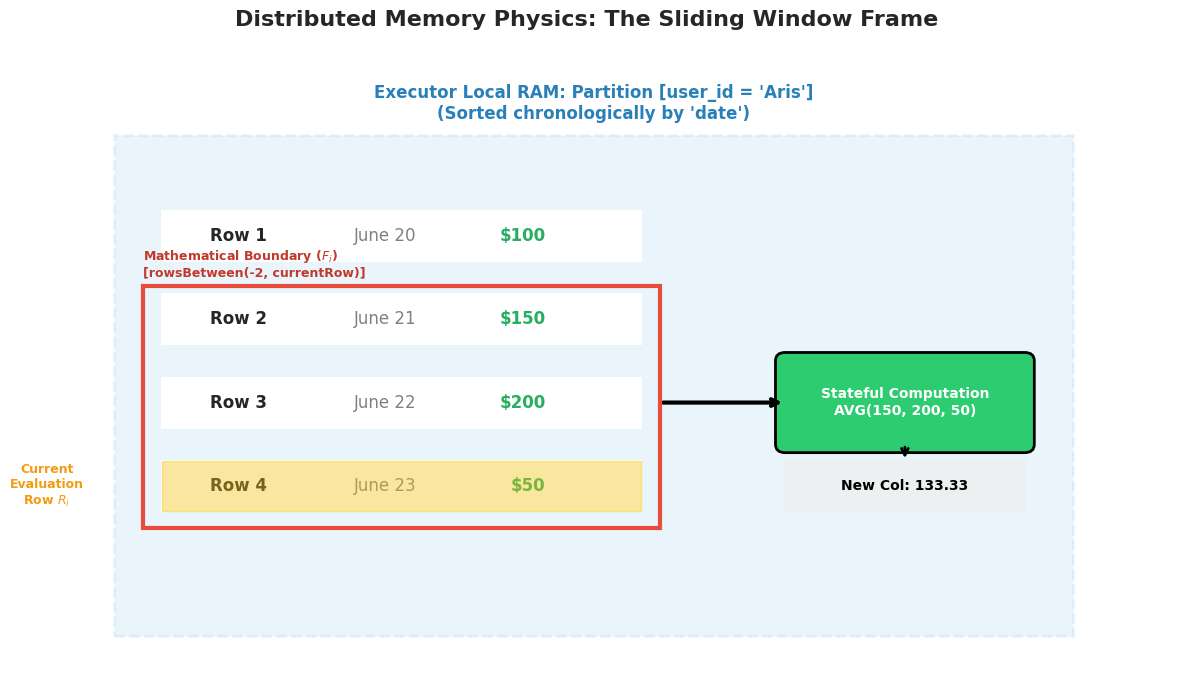

In [4]:
# Visualizing the Window Function Frame Physics
fig, ax = plt.subplots(figsize=(12, 7))
fig.suptitle("Distributed Memory Physics: The Sliding Window Frame", fontsize=16, fontweight='bold')

ax.axis('off')

# 1. Define Partition Boundary (Executor RAM)
partition_box = patches.Rectangle((1, 0.5), 10, 6, fill=True, color='#3498db', alpha=0.1, edgecolor='black', linewidth=2, linestyle='--')
ax.add_patch(partition_box)
ax.text(6, 6.7, "Executor Local RAM: Partition [user_id = 'Aris']\n(Sorted chronologically by 'date')", ha='center', color='#2980b9', fontweight='bold', fontsize=12)

# 2. Draw Data Rows (The underlying DataFrame)
# y-coordinates for 4 rows
row_y = [5.0, 4.0, 3.0, 2.0]
dates = ["June 20", "June 21", "June 22", "June 23"]
revs = [100, 150, 200, 50]

for i, y in enumerate(row_y):
    # Base row box
    ax.add_patch(patches.Rectangle((1.5, y), 5, 0.6, fill=True, color='white', edgecolor='black', linewidth=1.5))
    ax.text(2.0, y+0.3, f"Row {i+1}", fontweight='bold', va='center')
    ax.text(3.5, y+0.3, f"{dates[i]}", va='center', color='gray')
    ax.text(5.5, y+0.3, f"${revs[i]}", ha='right', va='center', fontweight='bold', color='#27ae60')

# 3. Draw Bounding Frame (Sliding Window memory state targeting Row 4)
# We are showing the evaluation frame for the final row (Row 4).
# It bounds Row 2, Row 3, and Row 4.
frame_box = patches.Rectangle((1.3, 1.8), 5.4, 2.9, fill=False, edgecolor='#e74c3c', linewidth=3, zorder=4)
ax.add_patch(frame_box)
ax.text(1.3, 4.8, "Mathematical Boundary ($F_i$)\n[rowsBetween(-2, currentRow)]", color='#c0392b', fontweight='bold', fontsize=9)

# Highlight Current Row
highlight = patches.Rectangle((1.5, 2.0), 5.0, 0.6, fill=True, color='#f1c40f', alpha=0.4, zorder=3)
ax.add_patch(highlight)
ax.text(0.3, 2.3, "Current\nEvaluation\nRow $R_i$", ha='center', va='center', fontweight='bold', color='#f39c12', fontsize=9)

# 4. Draw Computation Logic (Aggregating the Frame)
ax.add_patch(patches.FancyBboxPatch((8.0, 2.8), 2.5, 1.0, boxstyle="round,pad=0.1", linewidth=2, edgecolor='black', facecolor='#2ecc71', zorder=3))
ax.text(9.25, 3.3, "Stateful Computation\nAVG(150, 200, 50)", ha='center', va='center', color='white', fontweight='bold', fontsize=10, zorder=4)

# Edges bridging frame to computation
ax.annotate("", xy=(8.0, 3.3), xytext=(6.7, 3.3), arrowprops=dict(arrowstyle="->", lw=3, color="black"))

# Output Column Result
ax.add_patch(patches.Rectangle((8.0, 2.0), 2.5, 0.6, fill=True, color='#ecf0f1', edgecolor='black', linewidth=1.5))
ax.text(9.25, 2.3, "New Col: 133.33", ha='center', va='center', color='black', fontweight='bold', fontsize=10)
ax.annotate("", xy=(9.25, 2.6), xytext=(9.25, 2.8), arrowprops=dict(arrowstyle="->", lw=2, color="black"))


plt.xlim(0, 12)
plt.ylim(0, 7.5)
plt.tight_layout()
plt.show()

## Real-World Use Case or Analogy:

Think of PySpark Window Functions like **A Bank Teller processing an Account Statement vs. A Vault Manager**:

* **`.groupBy()` (The Vault Manager)**: The vault manager is asked: *"How much money did Aris deposit in June?"* The manager takes all of Aris's individual deposit slips, throws them into a calculator, collapses them, and hands back a single number: `$500`. The individual daily deposit records are destroyed in the process. You cannot see the day-to-day history anymore.
* **Window Functions (The Bank Teller)**: A customer asks the teller to print a Bank Statement. The teller looks at the first day: `$100`. They write it down. They slide their finger down to the second day (`$150`), add it to their running memory state, and write `$250` next to it on the statement. They slide their finger down to the third day.
* The teller completes the entire month. The final printed piece of paper contains **both** the raw, uncollapsed daily transaction rows **and** the new calculated running-balance column mathematically attached to each row.

By defining physical `rowsBetween` boundaries, Data Engineers can compute massive sequential logic without ever sacrificing the underlying topological granularity of their Enterprise data tables.